In [146]:
# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import holoviews as hv
import matplotlib.pyplot as plt

import gpmap.plot.mpl as mplot
import gpmap.plot.ply as pplot
import gpmap.plot.ds as dplot

from scipy.stats import pearsonr   
from gpmap.datasets import DataSet, list_available_datasets
from gpmap.space import SequenceSpace
from gpmap.inference import LocalEpistasisRegression, MinimumEpistasisInterpolator, VCregression

In [4]:
dataset = DataSet('smn1')
data = dataset.data
data

,y,y_var
seq,,
AAACAAAA,0.223881,0.001738
AAACAAAC,0.514961,0.009195
AAACAAAG,0.208009,0.001500
AAACAAAU,0.235378,0.002109
AAACAACA,0.357162,0.004423
...,...,...
UUUUUUGU,0.199017,0.001373
UUUUUUUA,0.074571,0.000536
UUUUUUUC,0.193181,0.001294


In [92]:
X, y, y_var = data.index.values, data.y.values, data.y_var.values
idx = np.random.uniform(0, 1, size=X.shape[0]) < 0.1
X_train, y_train, y_var_train = X[idx], y[idx], y_var[idx]
X_test, y_test, y_var_test = X[~idx], y[~idx], y_var[~idx]

AttributeError: 'DataFrame' object has no attribute 'y'

In [57]:
model = LocalEpistasisRegression(seq_length=8, n_alleles=4, alphabet_type='rna', P=2)
model.fit(X_train, y_train, y_var=y_var_train)

In [41]:
sites = np.array([''.join(x) for x in  np.array(model.aligner.U_sites).astype(int).astype(str)])
d = [x.count('1') for x in sites]
corrs = model.cov / model.cov[0]
pred = model.aligner.predict(model.a_values)
space = SequenceSpace(X=sites, y=corrs)
nodes_df = pd.DataFrame({'d': d, 'corr': corrs, 'pred': pred / pred[0], 'dj': np.random.normal(d, scale=0.05)}, index=sites)
edges_df = space.get_edges_df()

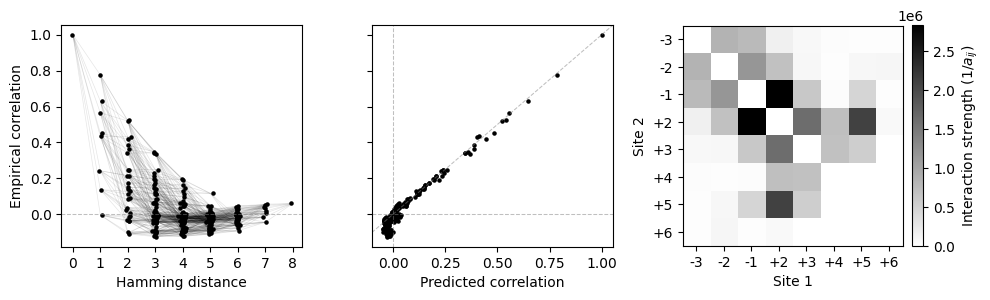

In [71]:
fig, subplots  = plt.subplots(1, 3, figsize=(10, 3))

axes = subplots[0]
axes.scatter(nodes_df['dj'], nodes_df['corr'], color='black', s=5)
mplot.plot_edges(axes, nodes_df, edges_df, x='d', y='corr', alpha=0.1, color='black')
axes.axhline(0, color="grey", linestyle="--", lw=0.75, alpha=0.5)
axes.set(xlabel='Hamming distance', ylabel='Empirical correlation', xticks=np.arange(9))

axes = subplots[1]
axes.scatter(nodes_df["pred"], nodes_df["corr"], color="black", s=5)
axes.set(xlabel="Predicted correlation", yticklabels=[])
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)
axes.axhline(0, color="grey", linestyle="--", lw=0.75, alpha=0.5)
axes.axvline(0, color="grey", linestyle="--", lw=0.75, alpha=0.5)

axes = subplots[2]
m = np.zeros((8, 8))
for (i, j), v in zip(model.Us, model.a_values):
    m[i, j] = 1 / v
    m[j, i] = 1 / v
im = axes.imshow(m, cmap="binary")
labels = ['-3', '-2', '-1', '+2', '+3', '+4', '+5', '+6']
axes.set(
    xlabel="Site 1",
    ylabel="Site 2",
    xticks=np.arange(8),
    yticks=np.arange(8),
    xticklabels=labels,
    yticklabels=labels,
)
plt.colorbar(im, ax=axes, fraction=0.046, pad=0.04, label='Interaction strength ($1/a_{ij}$)')

fig.tight_layout()

In [149]:
dmsc = DataSet('dmsc')
data = dmsc.data
X, y, y_var = data.index.values, data.m.values, data['var'].values +1e-4
idx = np.random.uniform(0, 1, size=X.shape[0]) < 0.99
X_train, y_train, y_var_train = X[idx], y[idx], y_var[idx]
X_test, y_test, y_var_test = X[~idx], y[~idx], y_var[~idx]

In [134]:
model = LocalEpistasisRegression(seq_length=9, n_alleles=4, alphabet_type='rna', P=2)
model.fit(X_train, y_train, y_var=y_var_train)

In [135]:
sites = np.array([''.join(x) for x in  np.array(model.aligner.U_sites).astype(int).astype(str)])
d = [x.count('1') for x in sites]
corrs = model.cov / model.cov[0]
pred = model.aligner.predict(model.a_values)
space = SequenceSpace(X=sites, y=corrs)
nodes_df = pd.DataFrame({'d': d, 'corr': corrs, 'pred': pred / pred[0], 'dj': np.random.normal(d, scale=0.05)}, index=sites)
edges_df = space.get_edges_df()

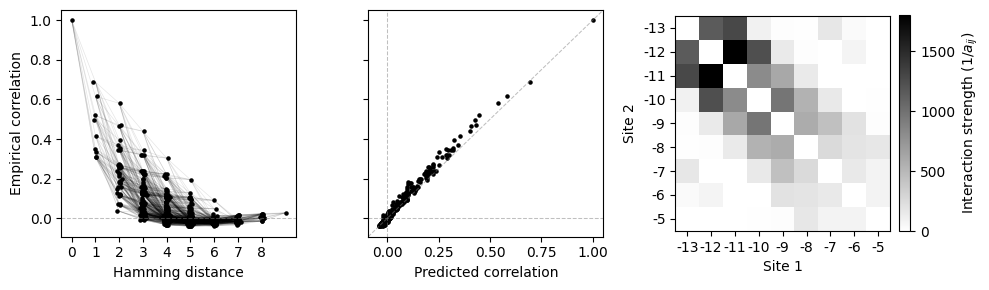

In [136]:
fig, subplots  = plt.subplots(1, 3, figsize=(10, 3))

axes = subplots[0]
axes.scatter(nodes_df['dj'], nodes_df['corr'], color='black', s=5)
mplot.plot_edges(axes, nodes_df, edges_df, x='d', y='corr', alpha=0.1, color='black')
axes.axhline(0, color="grey", linestyle="--", lw=0.75, alpha=0.5)
axes.set(xlabel='Hamming distance', ylabel='Empirical correlation', xticks=np.arange(model.seq_length))

axes = subplots[1]
axes.scatter(nodes_df["pred"], nodes_df["corr"], color="black", s=5)
axes.set(xlabel="Predicted correlation", yticklabels=[])
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)
axes.axhline(0, color="grey", linestyle="--", lw=0.75, alpha=0.5)
axes.axvline(0, color="grey", linestyle="--", lw=0.75, alpha=0.5)

axes = subplots[2]
m = np.zeros((model.seq_length, model.seq_length))
for (i, j), v in zip(model.Us, model.a_values):
    m[i, j] = 1 / v
    m[j, i] = 1 / v
im = axes.imshow(m, cmap="binary")
labels = -np.arange(5, 5 + model.seq_length)[::-1]
axes.set(
    xlabel="Site 1",
    ylabel="Site 2",
    xticks=np.arange(model.seq_length),
    yticks=np.arange(model.seq_length),
    xticklabels=labels,
    yticklabels=labels,
)
plt.colorbar(im, ax=axes, fraction=0.046, pad=0.04, label='Interaction strength ($1/a_{ij}$)')

fig.tight_layout()

In [137]:
pred = model.predict()

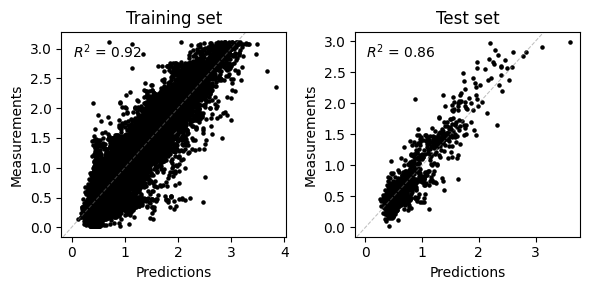

In [138]:
fig, subplots = plt.subplots(1, 2, figsize=(6, 3))

axes = subplots[0]
f_pred_train = pred.loc[X_train, 'f']
axes.scatter(f_pred_train, y_train, color="black", s=5)
r2 = pearsonr(f_pred_train, y_train)[0] ** 2
axes.set(xlabel='Predictions', ylabel='Measurements', title='Training set')
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

axes = subplots[1]
f_pred_test = pred.loc[X_test, 'f']
axes.scatter(f_pred_test, y_test, color="black", s=5)
r2 = pearsonr(f_pred_test, y_test)[0]**2
axes.set(xlabel="Predictions", ylabel="Measurements", title="Test set")
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

fig.tight_layout()

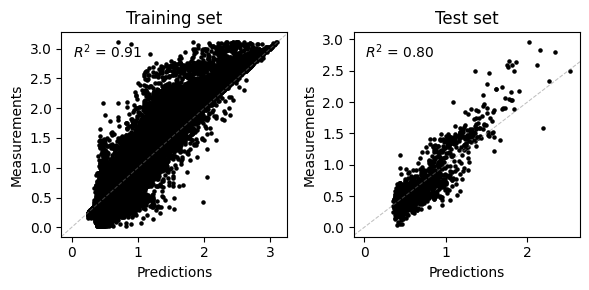

In [150]:
model = MinimumEpistasisInterpolator(seq_length=9, n_alleles=4, alphabet_type='rna', P=2)
model.fit(X_train, y_train, y_var=y_var_train)
pred = model.predict()

fig, subplots = plt.subplots(1, 2, figsize=(6, 3))

axes = subplots[0]
f_pred_train = pred.loc[X_train, 'f']
axes.scatter(f_pred_train, y_train, color="black", s=5)
r2 = pearsonr(f_pred_train, y_train)[0] ** 2
axes.set(xlabel='Predictions', ylabel='Measurements', title='Training set')
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

axes = subplots[1]
f_pred_test = pred.loc[X_test, 'f']
axes.scatter(f_pred_test, y_test, color="black", s=5)
r2 = pearsonr(f_pred_test, y_test)[0]**2
axes.set(xlabel="Predictions", ylabel="Measurements", title="Test set")
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

fig.tight_layout()

### GB1 dataset

In [185]:
dmsc = DataSet("gb1")
data = dmsc.data
X, y, y_var = data.index.values, data.y.values, data.y_var.values + 1e-4
idx = np.random.uniform(0, 1, size=X.shape[0]) < 0.2
X_train, y_train, y_var_train = X[idx], y[idx], y_var[idx]
X_test, y_test, y_var_test = X[~idx], y[~idx], y_var[~idx]

In [186]:
model = LocalEpistasisRegression(seq_length=4, n_alleles=20, alphabet_type='protein', P=2)
model.fit(X_train, y_train, y_var=y_var_train)

In [187]:
sites = np.array([''.join(x) for x in  np.array(model.aligner.U_sites).astype(int).astype(str)])
d = [x.count('1') for x in sites]
corrs = model.cov / model.cov[0]
pred = model.aligner.predict(model.a_values)
space = SequenceSpace(X=sites, y=corrs)
nodes_df = pd.DataFrame({'d': d, 'corr': corrs, 'pred': pred / pred[0], 'dj': np.random.normal(d, scale=0.05)}, index=sites)
edges_df = space.get_edges_df()

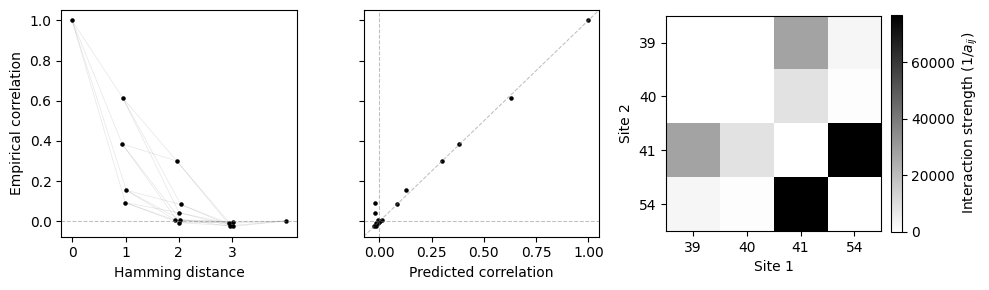

In [188]:
fig, subplots  = plt.subplots(1, 3, figsize=(10, 3))

axes = subplots[0]
axes.scatter(nodes_df['dj'], nodes_df['corr'], color='black', s=5)
mplot.plot_edges(axes, nodes_df, edges_df, x='dj', y='corr', alpha=0.1, color='black')
axes.axhline(0, color="grey", linestyle="--", lw=0.75, alpha=0.5)
axes.set(xlabel='Hamming distance', ylabel='Empirical correlation', xticks=np.arange(model.seq_length))

axes = subplots[1]
axes.scatter(nodes_df["pred"], nodes_df["corr"], color="black", s=5)
axes.set(xlabel="Predicted correlation", yticklabels=[])
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)
axes.axhline(0, color="grey", linestyle="--", lw=0.75, alpha=0.5)
axes.axvline(0, color="grey", linestyle="--", lw=0.75, alpha=0.5)

axes = subplots[2]
m = np.zeros((model.seq_length, model.seq_length))
for (i, j), v in zip(model.Us, model.a_values):
    m[i, j] = 1 / v
    m[j, i] = 1 / v
im = axes.imshow(m, cmap="binary")
labels = [39, 40, 41, 54]
axes.set(
    xlabel="Site 1",
    ylabel="Site 2",
    xticks=np.arange(model.seq_length),
    yticks=np.arange(model.seq_length),
    xticklabels=labels,
    yticklabels=labels,
)
plt.colorbar(im, ax=axes, fraction=0.046, pad=0.04, label='Interaction strength ($1/a_{ij}$)')

fig.tight_layout()

In [189]:
pred = model.predict()
pred

,f
AAAA,0.433353
AAAC,-2.964931
AAAD,-2.669600
AAAE,-5.117945
AAAF,-4.088616
...,...
YYYS,-4.597283
YYYT,-3.051363
YYYV,-3.496191
YYYW,-5.179712


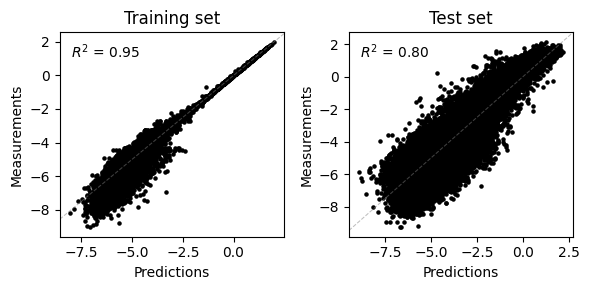

In [190]:
fig, subplots = plt.subplots(1, 2, figsize=(6, 3))

axes = subplots[0]
f_pred_train = pred.loc[X_train, 'f']
axes.scatter(f_pred_train, y_train, color="black", s=5)
r2 = pearsonr(f_pred_train, y_train)[0] ** 2
axes.set(xlabel='Predictions', ylabel='Measurements', title='Training set')
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

axes = subplots[1]
f_pred_test = pred.loc[X_test, 'f']
axes.scatter(f_pred_test, y_test, color="black", s=5)
r2 = pearsonr(f_pred_test, y_test)[0]**2
axes.set(xlabel="Predictions", ylabel="Measurements", title="Test set")
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

fig.tight_layout()

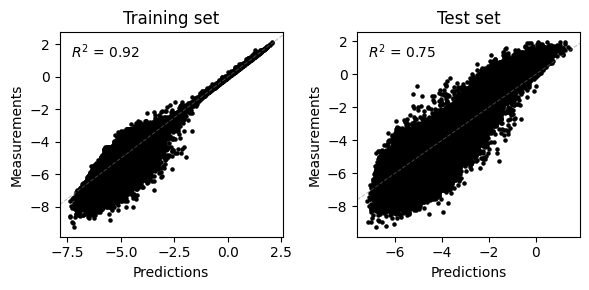

In [183]:
model = MinimumEpistasisInterpolator(seq_length=4, n_alleles=20, alphabet_type='protein', P=2)
model.fit(X_train, y_train, y_var=y_var_train)
pred = model.predict()

fig, subplots = plt.subplots(1, 2, figsize=(6, 3))

axes = subplots[0]
f_pred_train = pred.loc[X_train, 'f']
axes.scatter(f_pred_train, y_train, color="black", s=5)
r2 = pearsonr(f_pred_train, y_train)[0] ** 2
axes.set(xlabel='Predictions', ylabel='Measurements', title='Training set')
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

axes = subplots[1]
f_pred_test = pred.loc[X_test, 'f']
axes.scatter(f_pred_test, y_test, color="black", s=5)
r2 = pearsonr(f_pred_test, y_test)[0]**2
axes.set(xlabel="Predictions", ylabel="Measurements", title="Test set")
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

fig.tight_layout()

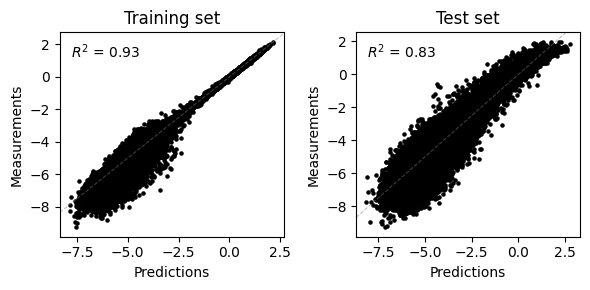

In [184]:
model = VCregression(seq_length=4, n_alleles=20, alphabet_type='protein')
model.fit(X_train, y_train, y_var=y_var_train)
pred = model.predict()

fig, subplots = plt.subplots(1, 2, figsize=(6, 3))

axes = subplots[0]
f_pred_train = pred.loc[X_train, 'f']
axes.scatter(f_pred_train, y_train, color="black", s=5)
r2 = pearsonr(f_pred_train, y_train)[0] ** 2
axes.set(xlabel='Predictions', ylabel='Measurements', title='Training set')
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

axes = subplots[1]
f_pred_test = pred.loc[X_test, 'f']
axes.scatter(f_pred_test, y_test, color="black", s=5)
r2 = pearsonr(f_pred_test, y_test)[0]**2
axes.set(xlabel="Predictions", ylabel="Measurements", title="Test set")
axes.text(0.05, 0.95, f'$R^2$ = {r2:.2f}', transform=axes.transAxes, va='top', ha='left')
axes.axline((0, 0), slope=1, color="grey", linestyle="--", lw=0.75, alpha=0.5)

fig.tight_layout()